In [2]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt

root_dir = os.path.abspath("..")
if root_dir not in sys.path:
    sys.path.append(root_dir)

from current_setpoints.models.machines import ieee_machine2_trained_neural_flux
from current_setpoints.models.forward_model import ForwardModel, Fault, count_peaks_at_limit
from current_setpoints.optimization.dynamic_optimizer import IndependentOptimizer

CURR_MAX, VOLT_MAX = 30.0, 13.0
drive = ieee_machine2_trained_neural_flux(curr_max=CURR_MAX, volt_max=VOLT_MAX)

solver_opts = {"disp": False, "ftol": 1e-8, "maxiter": 300}
N_GRID = 90

# rpm = omega_elec * CONST_MECH_SPEED -- same conversion optimization/grid.py
# uses for its own vec_omega/rpm labeling, so a point picked here by
# mechanical RPM lines up with the same axis the maps are plotted on.
CONST_MECH_SPEED = 30.0 / (np.pi * drive.n_ppairs)

PHASE_LETTERS = ["a", "b", "c", "d", "e"]

FAULT_MODES = {
    "healthy": (),
    "1-fault": (4,),
    "2-adj": (3, 4),
    "2-non-adj": (2, 4),
}

CONTEXTS = {}
for _name, _open_phases in FAULT_MODES.items():
    _fwd = ForwardModel(drive, fault=Fault(_open_phases), n_theta=700)
    CONTEXTS[_name] = {
        "fwd": _fwd,
        "pointwise": IndependentOptimizer(_fwd, solver_opts, n_grid=N_GRID),
    }

In [3]:
def segment_label(n_curr, n_volt):
    roman = {0: "", 1: "I", 2: "II"}
    return f"MTPA_{n_curr}" if n_volt == 0 else f"FW_{roman[n_volt]},{n_curr}"


def fine_idx_grid(fwd, theta_grid):
    n_theta = fwd.vec_theta.size - 1
    return np.round(theta_grid / (2 * np.pi) * n_theta).astype(int) % n_theta


def reconstruct_phase_currents(fwd, theta_grid, sched):
    idx_grid = fine_idx_grid(fwd, theta_grid)
    n_surv = fwd.phase_map_at_theta(0).shape[0]
    out = np.full((n_surv, len(idx_grid)), np.nan)
    for k, ti in enumerate(idx_grid):
        if np.all(np.isfinite(sched[k])):
            out[:, k] = fwd.phase_map_at_theta(int(ti)) @ sched[k]
    return out


def reconstruct_phase_voltages(fwd, theta_grid, sched, omega):
    # gU @ i_n + bV at each node's own angle and own current -- same
    # linearization-free reconstruction optimization/grid.py's own
    # _trajectory_waveforms uses for IndependentOptimizer trajectories
    # (exact for it: this is exactly the per-node constraint it enforced).
    idx_grid = fine_idx_grid(fwd, theta_grid)
    kept = list(fwd.fault._kept)
    out = np.full((len(kept), len(idx_grid)), np.nan)
    for k, ti in enumerate(idx_grid):
        i_n = sched[k]
        if np.all(np.isfinite(i_n)):
            gU, _, bV = fwd.volt_map_at_theta(int(ti), omega, i_n)
            out[:, k] = (gU @ i_n + bV)[kept]
    return out


def alpha_beta_xy(theta_grid, sched):
    # Rotating dq (id1,iq1,id3,iq3) -> stationary alpha-beta (harmonic 1) and
    # x-y (harmonic 3) frames, same R(theta) block convention used throughout
    # this repo's fault reconstruction code.
    c1, s1 = np.cos(theta_grid), np.sin(theta_grid)
    c3, s3 = np.cos(3 * theta_grid), np.sin(3 * theta_grid)
    id1, iq1, id3, iq3 = sched[:, 0], sched[:, 1], sched[:, 2], sched[:, 3]
    i_alpha = c1 * id1 - s1 * iq1
    i_beta = s1 * id1 + c1 * iq1
    i_x = c3 * id3 - s3 * iq3
    i_y = s3 * id3 + c3 * iq3
    return i_alpha, i_beta, i_x, i_y

In [4]:
def plot_point(mode, torque, rpm):
    ctx = CONTEXTS[mode]
    fwd = ctx["fwd"]
    omega = rpm / CONST_MECH_SPEED  # mechanical RPM -> electrical rad/s

    sol_pw = ctx["pointwise"].minimize_current(torque, omega)
    if not np.any(sol_pw.diagnostics.get("ok_grid", [])):
        print(f"{mode}  T*={torque} Nm, {rpm} RPM: infeasible at every angle")
        return
    if not sol_pw.success:
        print(f"{mode}  T*={torque} Nm, {rpm} RPM: "
              f"pointwise did not converge at every angle -- plotting anyway "
              f"({int(np.sum(sol_pw.diagnostics['ok_grid']))}/{N_GRID} nodes ok)")

    sched = sol_pw.curr_dq
    theta_grid = sol_pw.diagnostics["theta_grid"]
    theta = np.rad2deg(theta_grid)

    iph = reconstruct_phase_currents(fwd, theta_grid, sched)
    vph = reconstruct_phase_voltages(fwd, theta_grid, sched, omega)
    i_alpha, i_beta, i_x, i_y = alpha_beta_xy(theta_grid, sched)

    n_curr = count_peaks_at_limit(np.concatenate([iph, iph[:, :1]], axis=1), CURR_MAX)
    n_volt = count_peaks_at_limit(np.concatenate([vph, vph[:, :1]], axis=1), VOLT_MAX)
    seg_text = segment_label(n_curr, n_volt)

    kept = list(fwd.fault._kept)
    letters = [PHASE_LETTERS[p] for p in kept]

    norm_pw = np.sum(sched ** 2, axis=1)
    cu_pw = np.nansum(iph ** 2, axis=0)

    fig, ax = plt.subplots(2, 4, figsize=(22, 9))
    fig.suptitle(f"{mode}  [{seg_text}]   T*={torque:.2f} Nm,  {rpm:.1f} RPM", fontsize=13)

    dq_lbl = [r"$i_{sd}^1$", r"$i_{sq}^1$", r"$i_{sd}^3$", r"$i_{sq}^3$"]
    dq_col = ["tab:blue", "tab:orange", "tab:green", "tab:red"]
    a = ax[0, 0]
    for j in range(fwd.drive.dim):
        a.plot(theta, sched[:, j], color=dq_col[j], label=dq_lbl[j])
    a.set_title("DQ setpoints")
    a.set_xlabel(r"$\theta$ [deg]"); a.set_ylabel("DQ current [A]")
    a.legend(fontsize=8)

    a = ax[0, 1]
    for p, lt in enumerate(letters):
        a.plot(theta, iph[p], label=f"$i_{{{lt}}}$")
    a.axhline(CURR_MAX, color="gray", ls=":"); a.axhline(-CURR_MAX, color="gray", ls=":")
    a.set_title("Phase currents")
    a.set_xlabel(r"$\theta$ [deg]"); a.set_ylabel("phase current [A]")
    a.legend(fontsize=8)

    a = ax[0, 2]
    for p, lt in enumerate(letters):
        a.plot(theta, vph[p], label=f"$v_{{{lt}}}$")
    a.axhline(VOLT_MAX, color="gray", ls=":"); a.axhline(-VOLT_MAX, color="gray", ls=":")
    a.set_title("Phase voltages")
    a.set_xlabel(r"$\theta$ [deg]"); a.set_ylabel("phase voltage [V]")
    a.legend(fontsize=8)

    a = ax[0, 3]
    a.plot(theta, cu_pw, color="tab:orange", label=f"mean={np.nanmean(cu_pw):.1f}")
    a.set_title(r"Copper-loss density $\sum_k i_k^2(\theta)$")
    a.set_xlabel(r"$\theta$ [deg]"); a.set_ylabel(r"$\sum_k i_k^2$ [A$^2$]")
    a.legend(fontsize=8)

    a = ax[1, 0]
    a.plot(theta, norm_pw, color="tab:orange", label=r"$\|i_s(\theta)\|^2$")
    a.set_title(r"DQ norm $\|i_s\|^2$")
    a.set_xlabel(r"$\theta$ [deg]"); a.set_ylabel(r"$\|i_s\|^2$ [A$^2$]")
    a.legend(fontsize=8)

    a = ax[1, 1]
    a.plot(i_alpha, i_beta, color="tab:purple")
    a.set_title(r"$\alpha\beta$ current")
    a.set_xlabel(r"$i_\alpha$ [A]"); a.set_ylabel(r"$i_\beta$ [A]")
    a.set_aspect("equal")

    a = ax[1, 2]
    a.plot(i_x, i_y, color="tab:brown")
    a.set_title("xy current")
    a.set_xlabel(r"$i_x$ [A]"); a.set_ylabel(r"$i_y$ [A]")
    a.set_aspect("equal")

    ax[1, 3].axis("off")

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

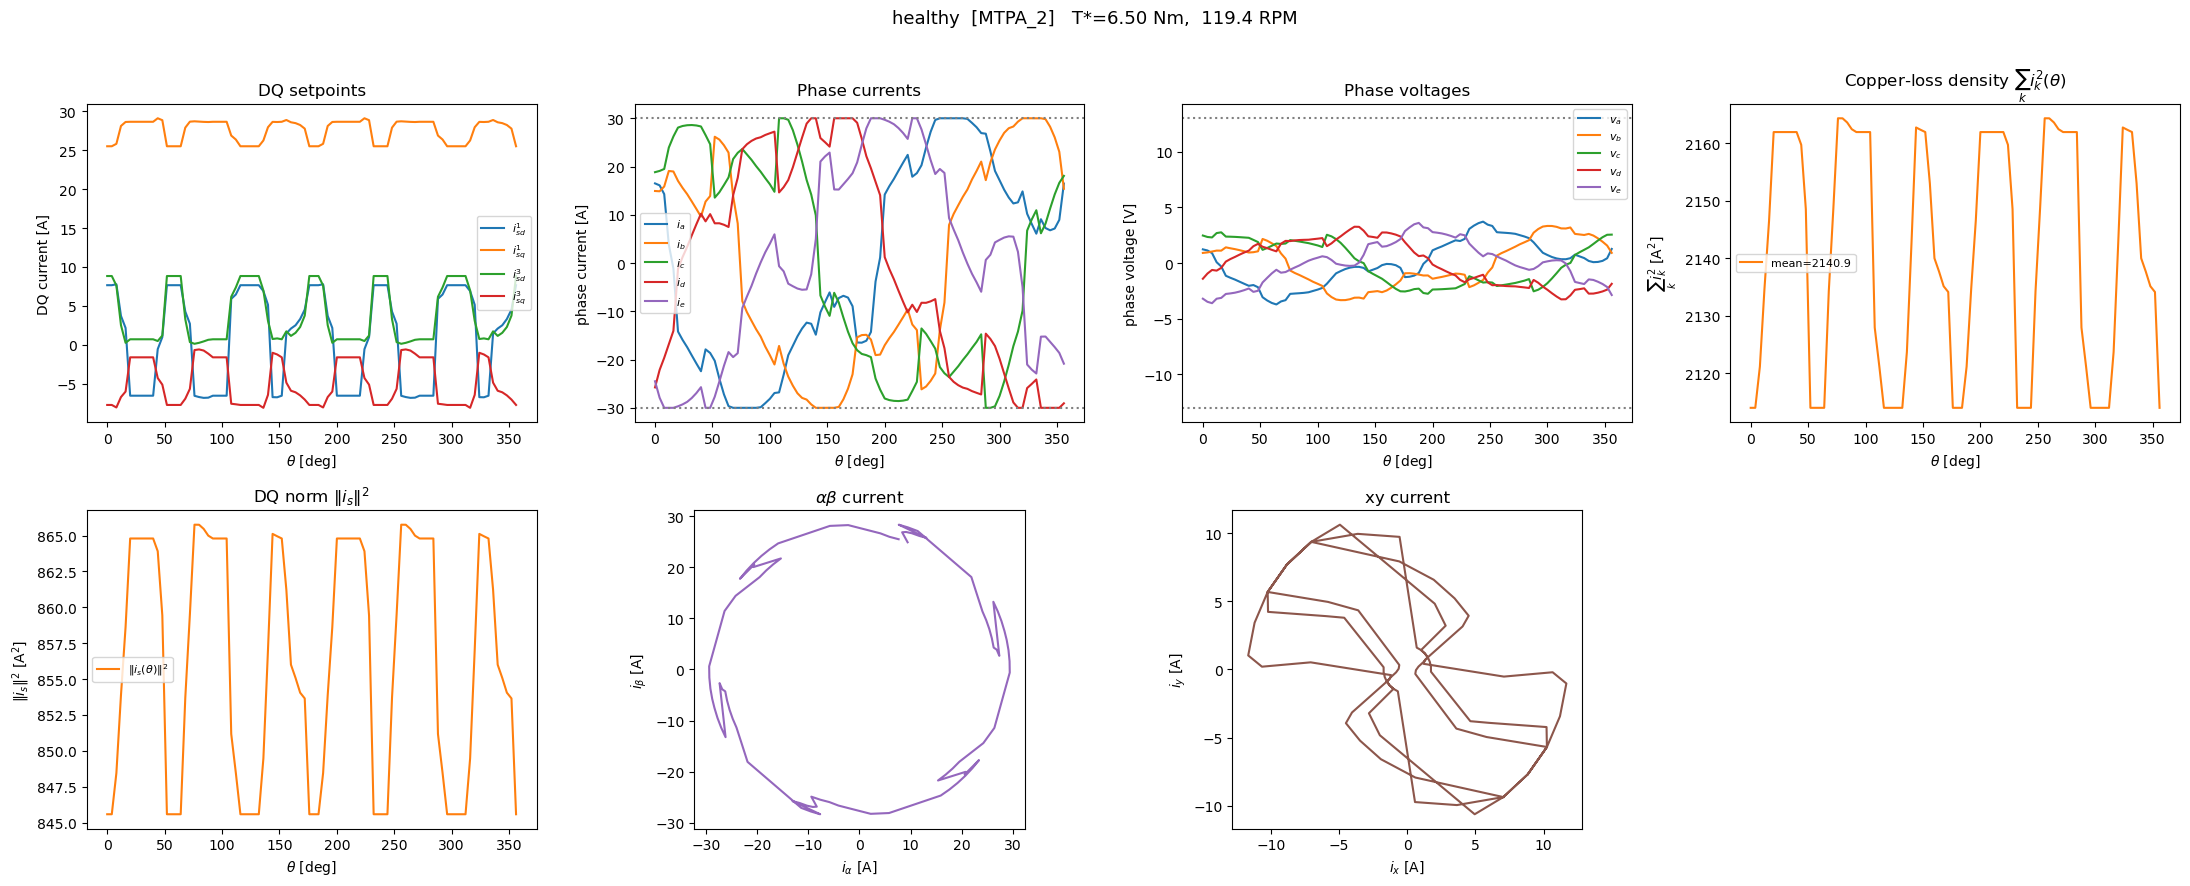

In [5]:
plot_point(mode="healthy", torque=6.5, rpm=119.4)

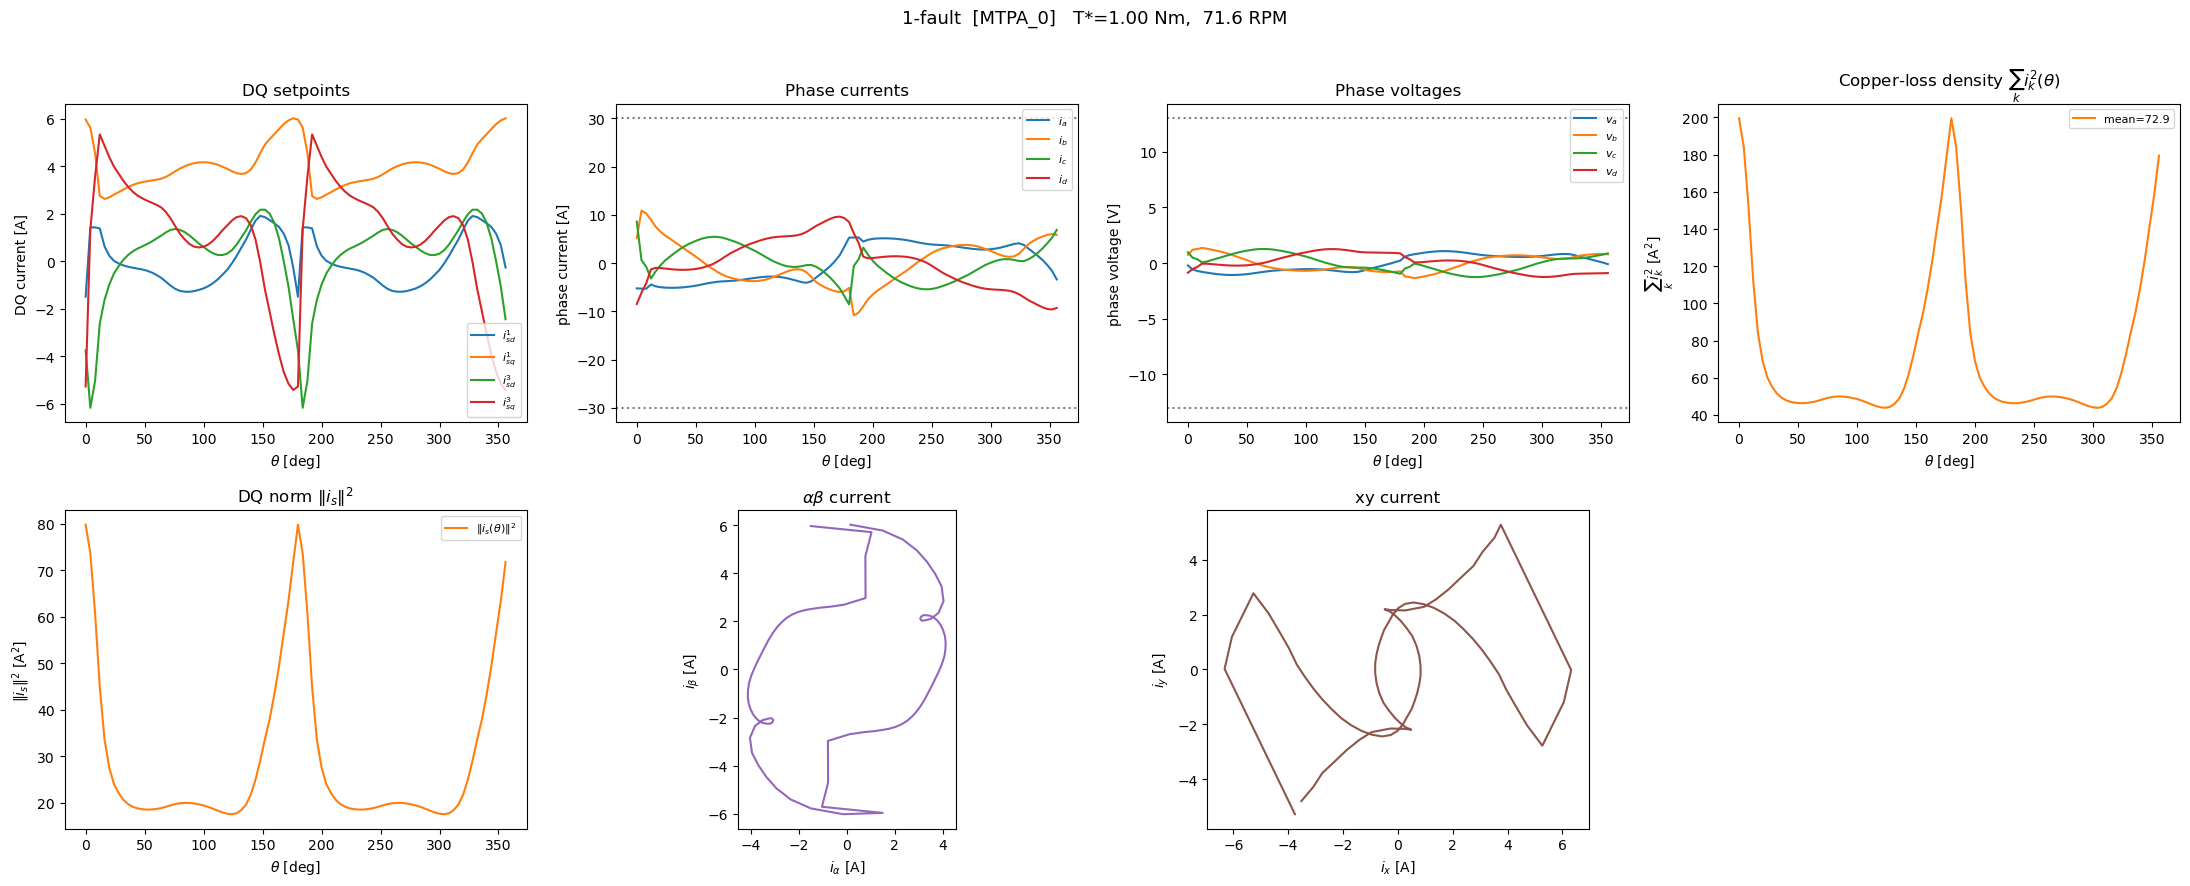

In [6]:
plot_point(mode="1-fault", torque=1.0, rpm=71.6)

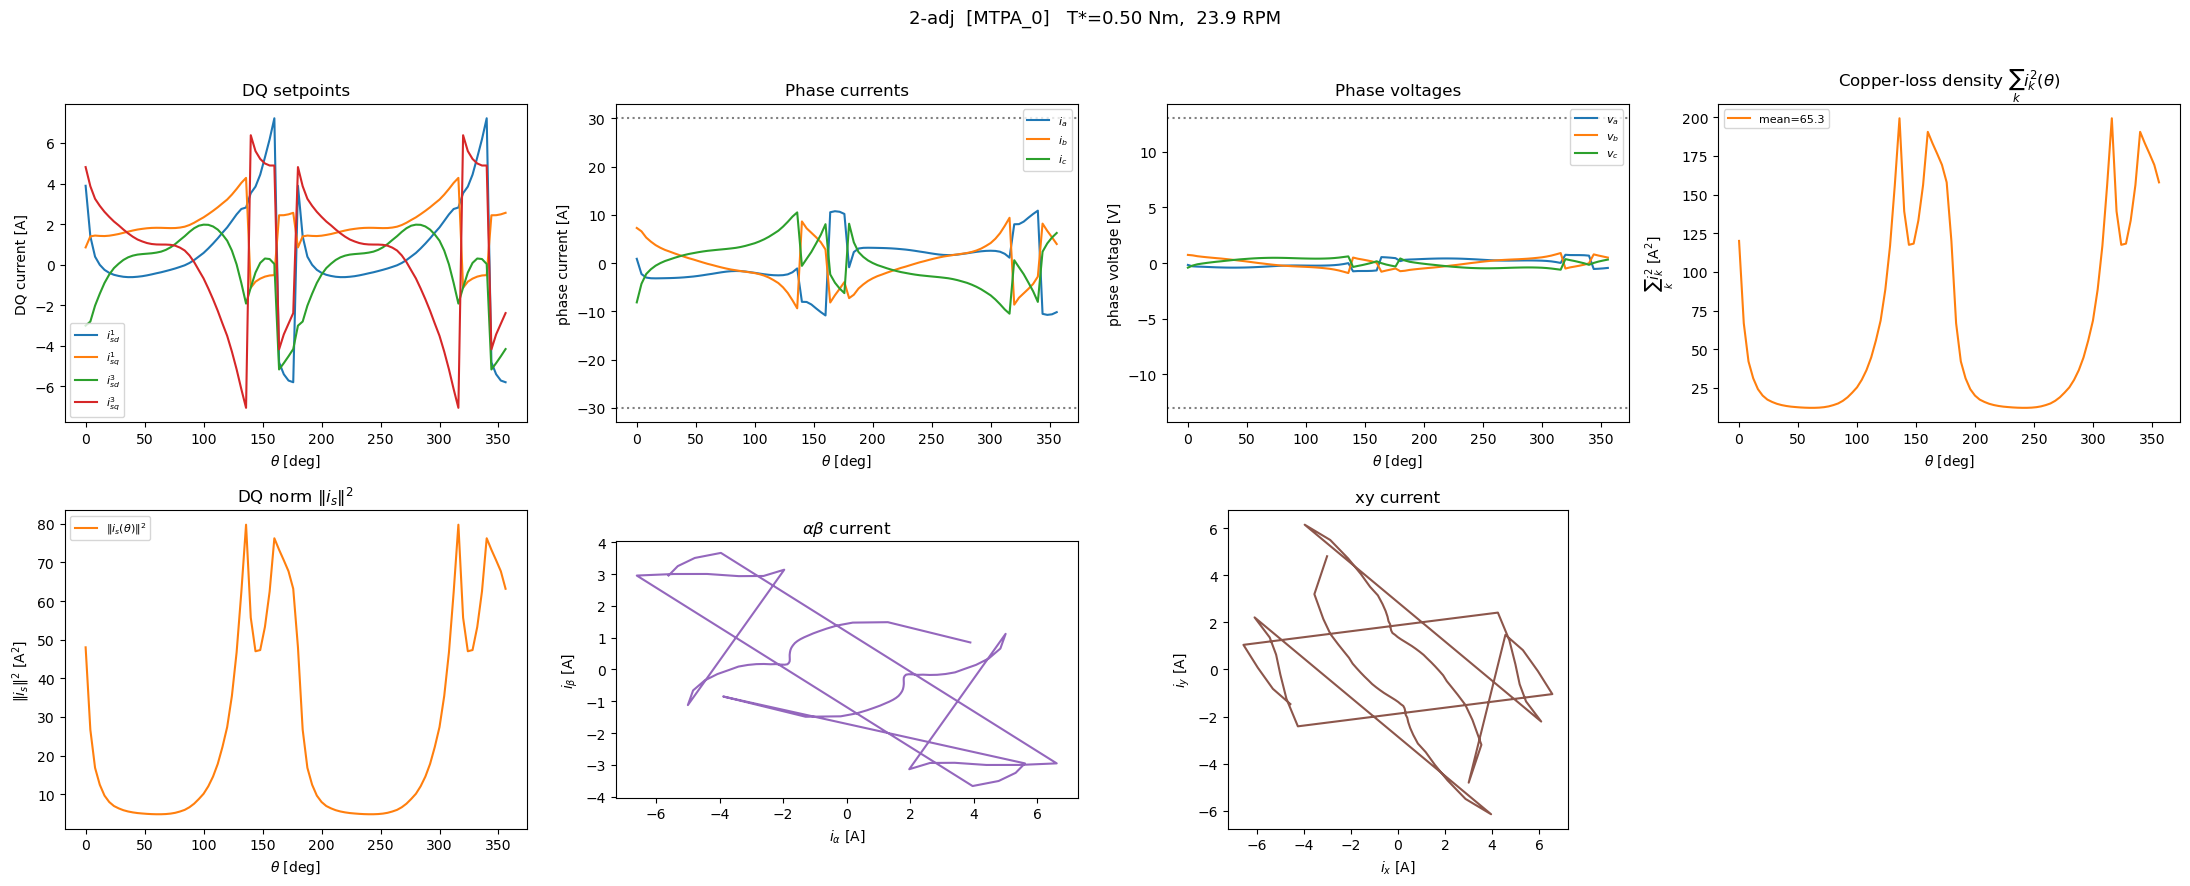

In [7]:
plot_point(mode="2-adj", torque=0.5, rpm=23.9)

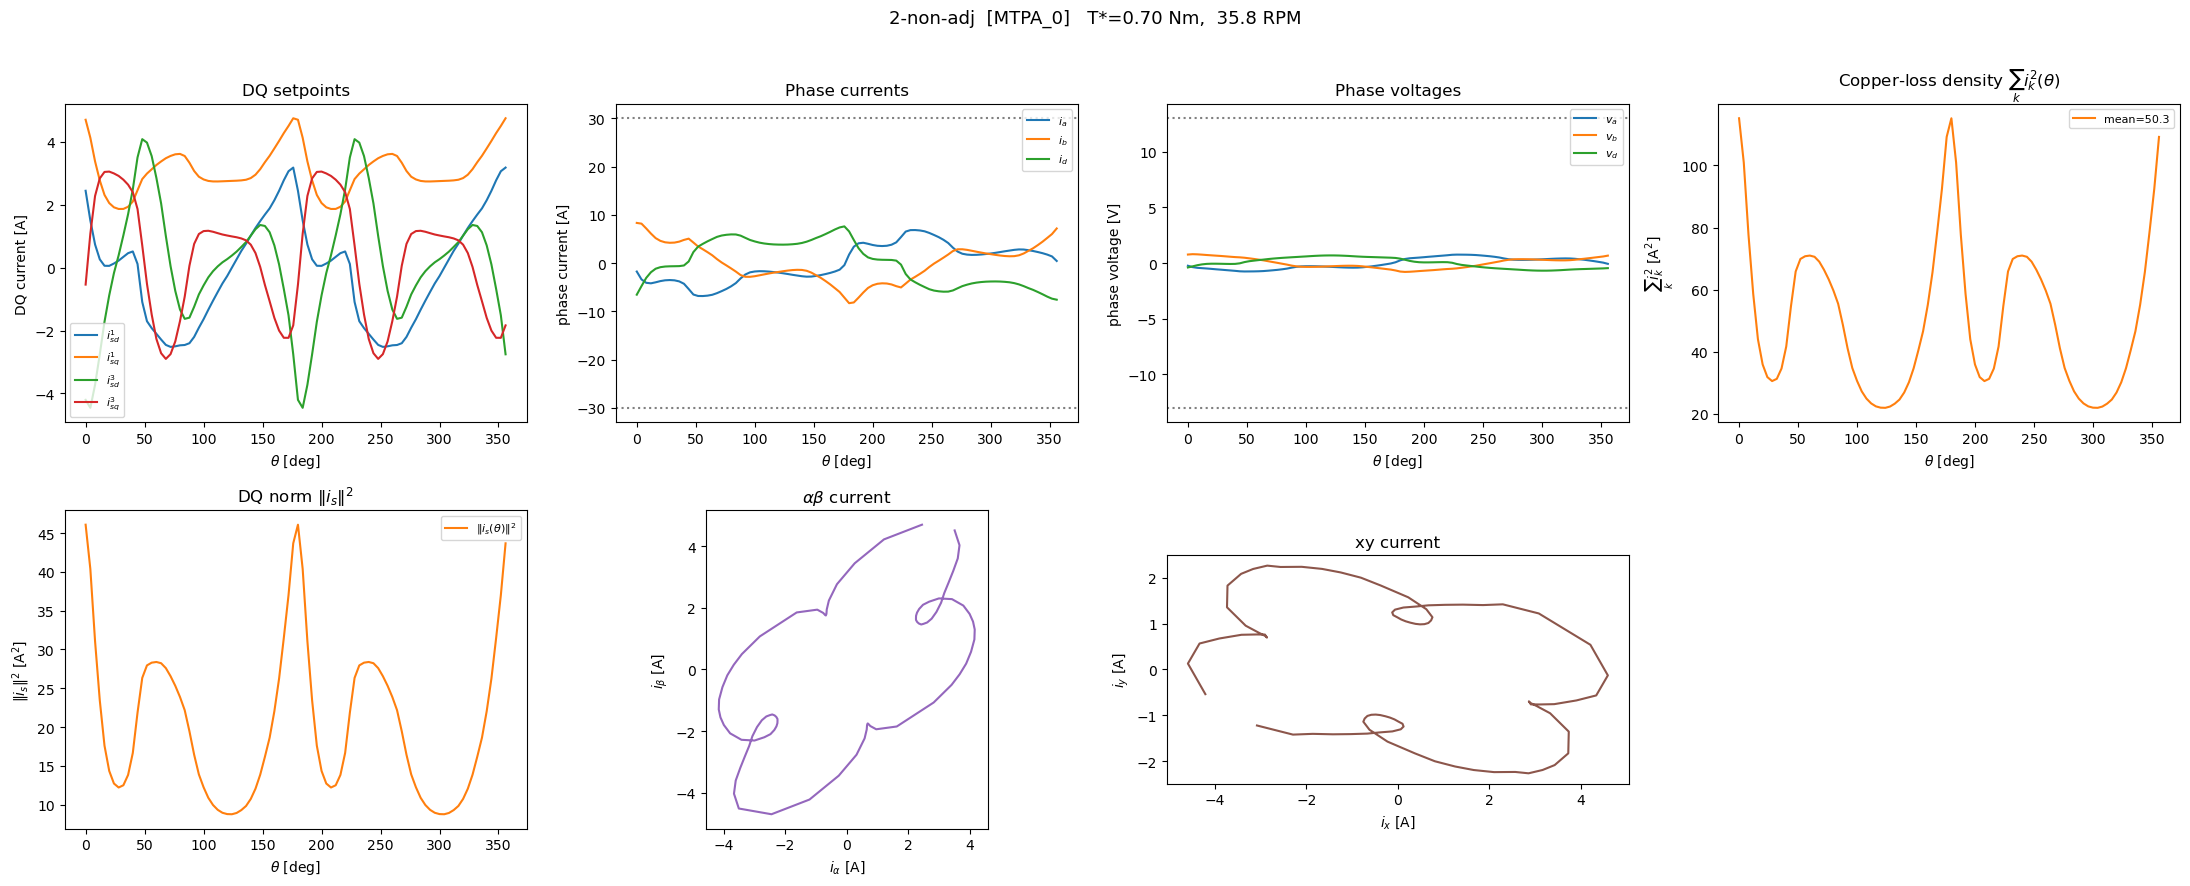

In [8]:
plot_point(mode="2-non-adj", torque=0.7, rpm=35.8)